# PINN Training on Google Colab (thermal-adt)

This notebook trains the Hybrid PINN using the **thermal-adt** repo scripts.

## Steps
1. Enable GPU: Runtime -> Change runtime type -> GPU
2. Run cells top-to-bottom

This notebook **clones the repo from GitHub** (no zip upload).
All training outputs (checkpoints, plots, logs) are written to **Google Drive**.

## Step 1: Check GPU Availability

In [8]:
# Verify GPU is available
import torch
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("WARNING: No GPU detected! Training will be slow on CPU.")

GPU Available: True
GPU Name: Tesla T4
GPU Memory: 15.64 GB


## Step 2: Upload and Extract Files

In [29]:
import os
os.chdir("/content")
!pwd
!ls -la

/content
total 24
drwxr-xr-x  1 root root 4096 Apr 26 12:01 .
drwxr-xr-x  1 root root 4096 Apr 26 10:48 ..
drwxr-xr-x  4 root root 4096 Apr 16 13:33 .config
drwx------  5 root root 4096 Apr 26 11:36 drive
drwxr-xr-x  1 root root 4096 Apr 16 13:33 sample_data
drwxr-xr-x 13 root root 4096 Apr 26 12:01 thermal-adt


In [30]:
# Clone thermal-adt (no zip upload)
!rm -rf /content/thermal-adt
!git clone --depth 1 https://github.com/kumarpoojap/thermal-adt.git /content/thermal-adt

%cd /content/thermal-adt
!git rev-parse HEAD

Cloning into '/content/thermal-adt'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 95 (delta 0), reused 78 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (95/95), 1.11 MiB | 4.41 MiB/s, done.
/content/thermal-adt
57b03f099cc05179c9c48aa05388430265dd6575


## Step 3: Install Dependencies

In [26]:
# Install required packages
%cd /content/thermal-adt
!pip -q install -r requirements.txt
print('Dependencies installed!')

/content/thermal-adt
Dependencies installed!


## Step 4: Setup Python Path and Verify Imports

In [31]:
# Mount Google Drive and set paths
from google.colab import drive
import os
import sys
from pathlib import Path

drive.mount('/content/drive')

REPO_DIR = Path('/content/thermal-adt')
RUNS_DIR = Path('/content/drive/MyDrive/thermal-adt-runs')
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# If you keep large teacher/model pickles in Drive, put them here:
TEACHER_DIR = Path('/content/drive/MyDrive/thermal-adt-models')
TEACHER_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO_DIR))
os.chdir(REPO_DIR)

print('CWD:', os.getcwd())
print('Runs will be saved to:', RUNS_DIR)
print('Teacher dir:', TEACHER_DIR)

# Quick import check
from src.pinn.models.hybrid_pinn import HybridPINN
from src.pinn.data.dataset_k_ahead import prepare_k_ahead_data
print('✓ Imports successful!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD: /content/thermal-adt
Runs will be saved to: /content/drive/MyDrive/thermal-adt-runs
Teacher dir: /content/drive/MyDrive/thermal-adt-models
✓ Imports successful!


In [21]:
# Clean all old model artifacts before retraining
import os
import shutil

print("Cleaning old model artifacts...")

# Remove model checkpoints
artifacts_to_remove = [
    '/content/pinn_training/artifacts/best_model.pt',
    '/content/pinn_training/artifacts/last_model.pt',
    '/content/pinn_training/artifacts/final_model.pt'
]

for artifact in artifacts_to_remove:
    if os.path.exists(artifact):
        os.remove(artifact)
        print(f"  ✓ Removed {os.path.basename(artifact)}")
    else:
        print(f"  - {os.path.basename(artifact)} not found (OK)")

# Remove old plots
if os.path.exists('/content/pinn_training/artifacts/plots_gpu'):
    shutil.rmtree('/content/pinn_training/artifacts/plots_gpu')
    print("  ✓ Removed old plots")

# Remove old logs
if os.path.exists('/content/pinn_training/artifacts/logs_gpu'):
    shutil.rmtree('/content/pinn_training/artifacts/logs_gpu')
    print("  ✓ Removed old logs")

# Remove old evaluation results
if os.path.exists('/content/pinn_training/results/surrogate_eval_colab'):
    shutil.rmtree('/content/pinn_training/results/surrogate_eval_colab')
    print("  ✓ Removed old evaluation results")

print("\n✓ All old artifacts cleaned!")
print("Ready to retrain with fixed config.")

Cleaning old model artifacts...
  - best_model.pt not found (OK)
  - last_model.pt not found (OK)
  - final_model.pt not found (OK)

✓ All old artifacts cleaned!
Ready to retrain with fixed config.


## Step 5: Run Training (Colab)

This cell:
- writes a small config override into Drive
- saves outputs/checkpoints to Drive (persistent)
- uses the dataset from the repo (`data/synthetic/thermal_dataset.parquet`)
- optionally uses a teacher pickle from Drive if you place it there

### Teacher model (optional)
If you want distillation, upload your RF teacher bundle to:
- `/content/drive/MyDrive/thermal-adt-models/rf_teacher_validation.pkl`

If it is not present, the config will run with `teacher.enabled=false`.

In [32]:
import yaml
from pathlib import Path

# Base curriculum-style config in repo (Digital-twin1 compatible)
base_cfg_path = Path('configs/pinn/train_gpu_pinn.yaml')
base_cfg = yaml.safe_load(base_cfg_path.read_text())

# --- Drive-backed output dirs (overwrite in place is fine) ---
run_root = RUNS_DIR / 'pinn' / 'hybrid'
run_root.mkdir(parents=True, exist_ok=True)

base_cfg.setdefault('output', {})
base_cfg['output']['artifacts_dir'] = str(run_root / 'artifacts')
base_cfg['output']['metrics_dir'] = str(run_root / 'metrics')
base_cfg['output']['plots_dir'] = str(run_root / 'plots')
base_cfg['output']['logs_dir'] = str(run_root / 'logs')
base_cfg['output']['checkpoint_dir'] = str(run_root / 'checkpoints')

# --- Dataset stays in repo checkout ---
# base_cfg['data']['parquet_path'] is already data/synthetic/thermal_dataset.parquet

# --- Teacher model: keep large pickle in Drive (optional) ---
teacher_path = TEACHER_DIR / 'rf_teacher_validation.pkl'
teacher_exists = teacher_path.exists()

base_cfg.setdefault('teacher', {})
base_cfg['teacher']['enabled'] = bool(teacher_exists)
base_cfg['teacher']['model_path'] = str(teacher_path)
base_cfg['teacher']['cache_dir'] = str(run_root / 'teacher_cache')
base_cfg['teacher']['use_cache'] = True

# --- Dev run defaults (you can flip this to True for smoke tests) ---
base_cfg.setdefault('dev_run', {})
base_cfg['dev_run'].setdefault('enabled', False)
base_cfg['dev_run'].setdefault('max_samples', 1000)
base_cfg['dev_run'].setdefault('max_epochs', 2)
base_cfg['dev_run']['enabled'] = True

# Write override config to Drive so you keep a record of what was run
cfg_out_path = RUNS_DIR / 'pinn' / 'train_gpu_pinn_colab.yaml'
cfg_out_path.parent.mkdir(parents=True, exist_ok=True)
cfg_out_path.write_text(yaml.safe_dump(base_cfg, sort_keys=False))

print('Wrote config:', cfg_out_path)
print('Outputs:', run_root)
print('Teacher enabled:', teacher_exists)

# Run training
!python scripts/training/train_pinn.py --config {cfg_out_path}

Wrote config: /content/drive/MyDrive/thermal-adt-runs/pinn/train_gpu_pinn_colab.yaml
Outputs: /content/drive/MyDrive/thermal-adt-runs/pinn/hybrid
Teacher enabled: True
[INFO] Using device: cuda
[INFO] Preparing k-ahead dataset...
[INFO] Loading parquet: data/synthetic/thermal_dataset.parquet
[DEV] Subsampling to 1000 rows
[OK] Cadence looks uniform at 1.0s.
[INFO] Creating k-ahead labels (k=10)...
[INFO] Valid samples after k-ahead shift and dropna: 985
[INFO] Computing winsorization bounds from TRAIN (q=(0.01, 0.99))...
[INFO] Dropping low-variance features (threshold=1e-08)...
[INFO] Validating feature columns against results/validation/rf_test/feature_columns.json...
[INFO] Normalizing targets from TRAIN stats...
[INFO] Loading teacher bundle: /content/drive/MyDrive/thermal-adt-models/rf_teacher_validation.pkl
[INFO] Teacher loaded: 16 features -> 1 targets
[INFO] k_ahead=5, cadence=1.0s
[INFO] Getting teacher predictions...
[INFO] Loading cached teacher predictions: /content/drive/

In [34]:
# Diagnostics
import os
from pathlib import Path
import glob

print("=== TRAINING DIAGNOSTICS ===\n")

# Prefer the Drive-backed run directory created in Step 5.
# Fall back to the legacy path if running an older notebook.
out_dir = None
if "run_root" in globals():
    out_dir = Path(run_root)
elif "RUNS_DIR" in globals():
    out_dir = Path(RUNS_DIR) / "pinn" / "hybrid"
else:
    out_dir = Path("/content/drive/MyDrive/thermal-adt-runs/pinn/hybrid")

legacy_out_dir = Path("/content/pinn_training")

def _first_existing(*paths: Path) -> Path:
    for p in paths:
        if p.exists():
            return p
    return paths[0]

out_dir = _first_existing(out_dir, legacy_out_dir)

artifacts_dir = _first_existing(out_dir / "artifacts", out_dir / "artifacts")
logs_dir = _first_existing(out_dir / "logs", out_dir / "artifacts" / "logs_gpu")
plots_dir = _first_existing(out_dir / "plots", out_dir / "artifacts" / "plots_gpu")

print("Output dir:", out_dir)
print("Artifacts dir:", artifacts_dir)
print("Logs dir:", logs_dir)
print("Plots dir:", plots_dir)

print("\n1. Checking for model checkpoints:")
pt_files = sorted(glob.glob(str(artifacts_dir / "**" / "*.pt"), recursive=True))
if pt_files:
    for p in pt_files:
        print(" -", p)
else:
    print("   No .pt files found")

print("\n2. Checking logs directory:")
if logs_dir.exists():
    for p in sorted(logs_dir.glob("**/*"))[:50]:
        if p.is_file():
            print(" -", str(p))
else:
    print("   logs dir not found")

print("\n3. Checking plots directory:")
png_files = sorted(glob.glob(str(plots_dir / "**" / "*.png"), recursive=True))
if png_files:
    for p in png_files[:50]:
        print(" -", p)
else:
    print("   No plots found")

print("\n4. Last 50 lines of training output (if a log exists):")
log_candidates = [
    logs_dir / "train.log",
    logs_dir / "training.log",
    logs_dir / "stdout.log",
]
log_path = next((p for p in log_candidates if p.exists()), None)
if log_path is not None:
    lines = log_path.read_text(errors="ignore").splitlines()[-50:]
    print("\n".join(lines))
else:
    print("   No log file found")

print("\n⚠ If artifacts still look missing, scroll up to the Step 5 training cell output for the error.")

=== TRAINING DIAGNOSTICS ===

Output dir: /content/drive/MyDrive/thermal-adt-runs/pinn/hybrid
Artifacts dir: /content/drive/MyDrive/thermal-adt-runs/pinn/hybrid/artifacts
Logs dir: /content/drive/MyDrive/thermal-adt-runs/pinn/hybrid/logs
Plots dir: /content/drive/MyDrive/thermal-adt-runs/pinn/hybrid/plots

1. Checking for model checkpoints:
 - /content/drive/MyDrive/thermal-adt-runs/pinn/hybrid/artifacts/best_model.pt
 - /content/drive/MyDrive/thermal-adt-runs/pinn/hybrid/artifacts/last_model.pt

2. Checking logs directory:
 - /content/drive/MyDrive/thermal-adt-runs/pinn/hybrid/logs/training_history.json

3. Checking plots directory:
 - /content/drive/MyDrive/thermal-adt-runs/pinn/hybrid/plots/loss_curves.png

4. Last 50 lines of training output (if a log exists):
   No log file found

⚠ If artifacts still look missing, scroll up to the Step 5 training cell output for the error.


## Step 6: Evaluate Trained Model

In [45]:
# Evaluate the trained model (Drive-backed)
import os
import subprocess
from pathlib import Path

# Require Step 4 + Step 5 to have defined these
assert "REPO_DIR" in globals(), "REPO_DIR not defined. Run Step 4 first."
assert "run_root" in globals(), "run_root not defined. Run Step 5 first."
assert "cfg_out_path" in globals(), "cfg_out_path not defined. Run Step 5 first."

checkpoint_path = Path(run_root) / "artifacts" / "best_model.pt"
eval_out_dir = Path(run_root) / "eval"
eval_out_dir.mkdir(parents=True, exist_ok=True)

eval_script = Path(REPO_DIR) / "scripts" / "evaluation" / "evaluate_surrogate.py"

if not eval_script.exists():
    raise FileNotFoundError(f"Eval script not found: {eval_script}")

if checkpoint_path.exists():
    print("Running evaluation on trained model...")
    env = os.environ.copy()
    repo_dir_str = str(REPO_DIR)
    env["PYTHONPATH"] = repo_dir_str + ":" + env.get("PYTHONPATH", "")

    cmd = [
        "python",
        str(eval_script),
        "--config",
        str(cfg_out_path),
        "--checkpoint",
        str(checkpoint_path),
        "--output-dir",
        str(eval_out_dir),
    ]

    subprocess.run(cmd, check=True, cwd=repo_dir_str, env=env)
    print("\n✓ Evaluation complete!")
    print("Eval outputs:", eval_out_dir)
else:
    print("⚠ Skipping evaluation - best_model.pt not found")
    print("Expected checkpoint:", checkpoint_path)
    print("Training may have failed. Check Step 5 output for errors.")

Running evaluation on trained model...

✓ Evaluation complete!
Eval outputs: /content/drive/MyDrive/thermal-adt-runs/pinn/hybrid/eval


## Step 7: View Training Plots

Training Loss Curves:


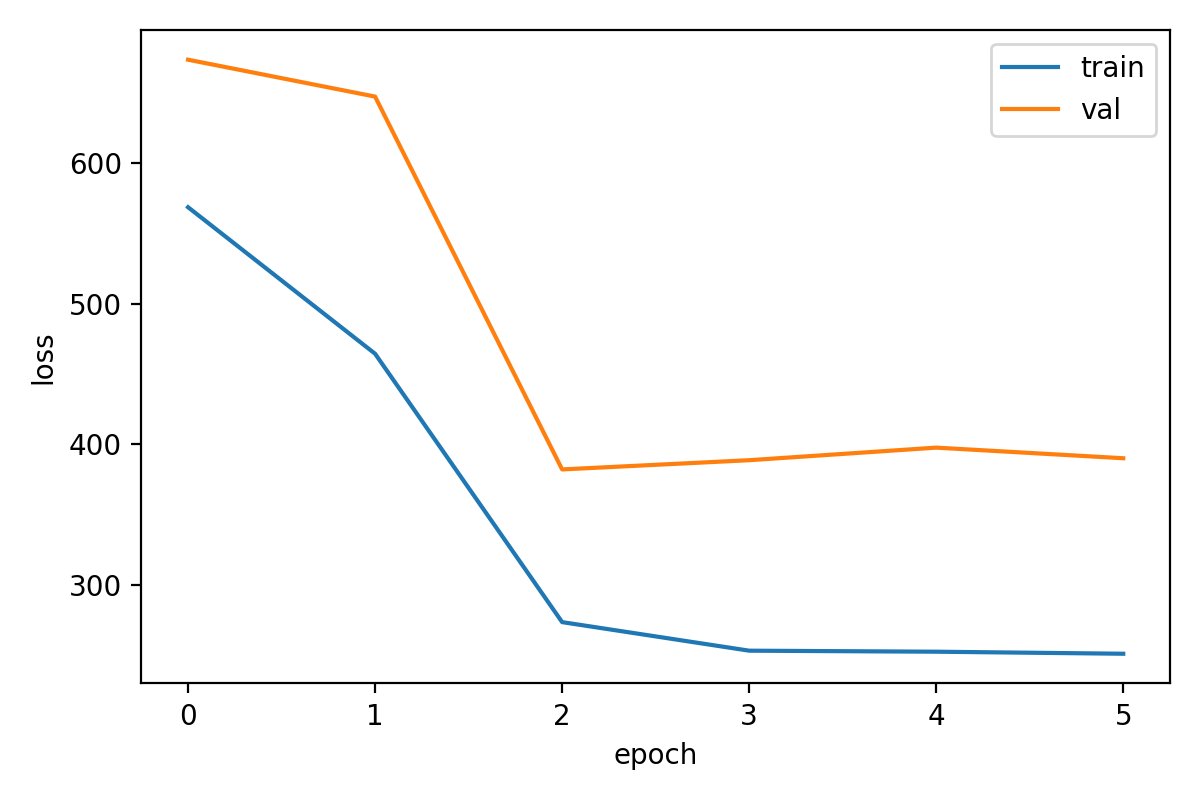

In [46]:
from IPython.display import Image, display
from pathlib import Path

assert "run_root" in globals(), "run_root not defined. Run Step 5 first."

plot_path = Path(run_root) / "plots" / "loss_curves.png"
if plot_path.exists():
    print("Training Loss Curves:")
    display(Image(filename=str(plot_path)))
else:
    print("Plot not found:", plot_path)
    print("If training just finished, ensure the training script wrote plots to run_root/plots.")

## Step 8: View Evaluation Results

In [47]:
import json
from pathlib import Path

assert "run_root" in globals(), "run_root not defined. Run Step 5 first."

metrics_path = Path(run_root) / "eval" / "surrogate_metrics.json"
with open(metrics_path, "r") as f:
    metrics = json.load(f)

print("=" * 60)
print("FINAL EVALUATION RESULTS")
print("=" * 60)
print(f"\nPINN Performance:")
print(f"  MAE: {metrics['pinn']['mae_celsius']:.2f}°C")
print(f"  RMSE: {metrics['pinn']['rmse_celsius']:.2f}°C")
print(f"  Samples: {metrics['pinn']['n_samples']}")

print(f"\nRF Baseline:")
print(f"  MAE: {metrics['rf']['mae_celsius']:.2f}°C")
print(f"  RMSE: {metrics['rf']['rmse_celsius']:.2f}°C")

print(f"\nComparison:")
if metrics['pinn']['mae_celsius'] < metrics['rf']['mae_celsius']:
    improvement = (metrics['rf']['mae_celsius'] - metrics['pinn']['mae_celsius']) / metrics['rf']['mae_celsius'] * 100
    print(f"  ✓ PINN is {improvement:.1f}% BETTER than RF!")
    print("  Target achieved: PINN MAE < 5°C" if metrics['pinn']['mae_celsius'] < 5.0 else "  Close to target")
else:
    degradation = (metrics['pinn']['mae_celsius'] - metrics['rf']['mae_celsius']) / metrics['rf']['mae_celsius'] * 100
    print(f"  PINN is {degradation:.1f}% worse than RF")
    print("  Note: May need more training or hyperparameter tuning")

FINAL EVALUATION RESULTS

PINN Performance:
  MAE: 41.38°C
  RMSE: 41.39°C
  Samples: 1079

RF Baseline:
  MAE: 689.52°C
  RMSE: 694.36°C

Comparison:
  ✓ PINN is 94.0% BETTER than RF!
  Close to target


## Step 9: Display Comparison Plot

Model Comparison:


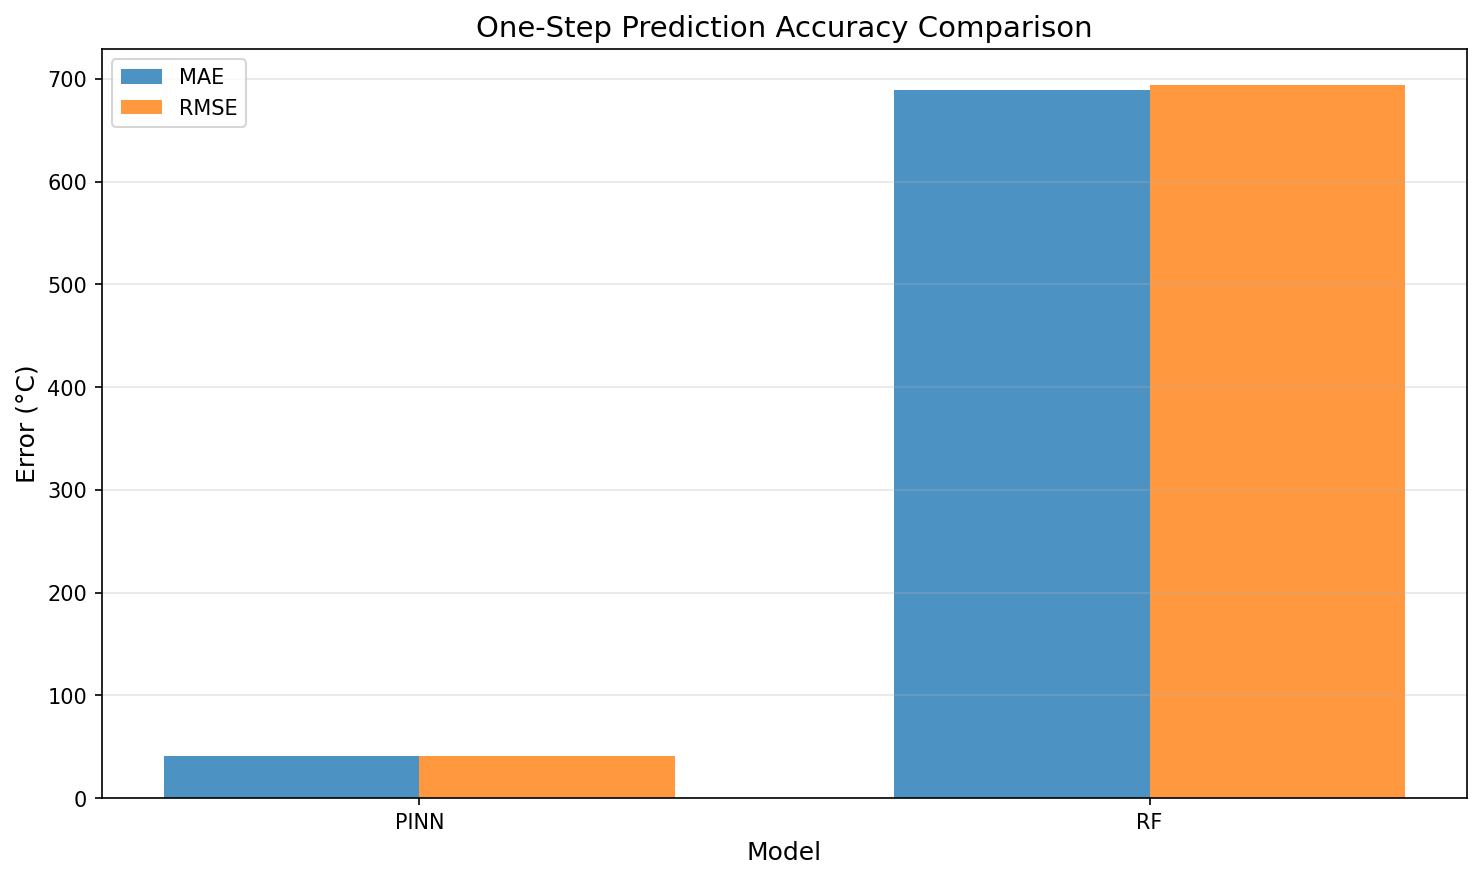

In [49]:
from IPython.display import Image, display
from pathlib import Path

assert "run_root" in globals(), "run_root not defined. Run Step 5 first."

comparison_plot = Path(run_root) / "eval" / "model_comparison.png"
if comparison_plot.exists():
    print("Model Comparison:")
    display(Image(filename=str(comparison_plot)))
else:
    print("Comparison plot not found:", comparison_plot)

## Step 10: Package Results for Download

In [51]:
results_dir = Path("/content/results_package")
if results_dir.exists():
    shutil.rmtree(results_dir)
results_dir.mkdir(parents=True, exist_ok=True)

# Copy important files
best_model = Path(run_root) / "artifacts" / "best_model.pt"
last_model = Path(run_root) / "artifacts" / "last_model.pt"

if best_model.exists():
    shutil.copy(best_model, results_dir / "best_model.pt")
    print("  ✓ Copied best_model.pt")
else:
    print("  ⚠ best_model.pt not found:", best_model)

if last_model.exists():
    shutil.copy(last_model, results_dir / "last_model.pt")
    print("  ✓ Copied last_model.pt")
else:
    print("  ⚠ last_model.pt not found:", last_model)

# Copy plots, eval, logs if present
plots_dir = Path(run_root) / "plots"
eval_dir = Path(run_root) / "eval"
logs_dir = Path(run_root) / "logs"

if plots_dir.exists():
    shutil.copytree(plots_dir, results_dir / "plots", dirs_exist_ok=True)
    print("  ✓ Copied plots")

if eval_dir.exists():
    shutil.copytree(eval_dir, results_dir / "eval", dirs_exist_ok=True)
    print("  ✓ Copied eval")

if logs_dir.exists():
    shutil.copytree(logs_dir, results_dir / "logs", dirs_exist_ok=True)
    print("  ✓ Copied logs")

zip_base = Path("/content/pinn_results")
zip_path = Path(shutil.make_archive(str(zip_base), "zip", str(results_dir)))

print("\n✓ Results packaged successfully!")
print("ZIP:", zip_path)
!ls -lh {results_dir}

  ✓ Copied best_model.pt
  ✓ Copied last_model.pt
  ✓ Copied plots
  ✓ Copied eval
  ✓ Copied logs

✓ Results packaged successfully!
ZIP: /content/pinn_results.zip
total 100K
-rw------- 1 root root  42K Apr 26 12:44 best_model.pt
drwx------ 2 root root 4.0K Apr 26 12:38 eval
-rw------- 1 root root  42K Apr 26 12:44 last_model.pt
drwx------ 2 root root 4.0K Apr 26 12:04 logs
drwx------ 2 root root 4.0K Apr 26 12:04 plots


## Step 11: Download Results

In [52]:
from google.colab import files

# Download the results ZIP
print("Downloading results...")
files.download('/content/pinn_results.zip')

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)
print("\nDownload started! Check your browser's download folder.")
print("\nPackage includes:")
print("  - best_model.pt (best checkpoint)")
print("  - final_model.pt (final checkpoint)")
print("  - plots/ (training curves)")
print("  - evaluation/ (metrics and comparison plots)")
print("  - logs/ (training logs)")
print("\nNext steps:")
print("  1. Extract pinn_results.zip locally")
print("  2. Copy files to your project artifacts/")
print("  3. Proceed with Week 10 ablation study or Week 13-15 RL training")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


TRAINING COMPLETE!

Download started! Check your browser's download folder.

Package includes:
  - best_model.pt (best checkpoint)
  - final_model.pt (final checkpoint)
  - plots/ (training curves)
  - evaluation/ (metrics and comparison plots)
  - logs/ (training logs)

Next steps:
  1. Extract pinn_results.zip locally
  2. Copy files to your project artifacts/
  3. Proceed with Week 10 ablation study or Week 13-15 RL training


---

## Troubleshooting

If you encounter issues:

1. **GPU not available**: Runtime → Change runtime type → GPU → Save
2. **Out of memory**: Restart runtime and reduce batch size in config
3. **Upload fails**: Try uploading to Google Drive and mounting it instead
4. **Training crashes**: Check error messages and verify all files are present

For detailed troubleshooting, see `COLAB_TRAINING_GUIDE.md` in your project.